<a href="https://colab.research.google.com/github/Gcostasilva/Python/blob/main/An%C3%A1lise%20Reviews%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
# ============================================================================
# PARTE 1: INSTALAÇÃO E IMPORTS
# ============================================================================
# Instale as bibliotecas necessárias (execute apenas uma vez)
"""
!pip install -q plotly scikit-learn wordcloud
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import warnings
warnings.filterwarnings('ignore')

# Configurar estilo dos gráficos
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Bibliotecas importadas com sucesso!")


✅ Bibliotecas importadas com sucesso!


In [18]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [22]:
# ============================================================================
# PARTE 2: FILTRAR REVIEWS NEGATIVAS
# ============================================================================
# Objetivo: Selecionar apenas reviews com score baixo (≤3) e com comentários

# Filtrar reviews com score baixo e comentários válidos
reviews_baixas = pd.read_csv('drive/MyDrive/Colab Notebooks/reviews_coment.csv')

In [23]:
reviews_baixas.shape

(17194, 1)


📊 DISTRIBUIÇÃO DE MOTIVOS
Outros........................  9916 ( 57.7%) ████████████████████████████
Entrega Atrasada..............  3188 ( 18.5%) █████████
Qualidade Ruim................  1036 (  6.0%) ███
Atendimento Ruim..............   967 (  5.6%) ██
Diferente da Descrição........   934 (  5.4%) ██
Produto Defeituoso............   586 (  3.4%) █
Embalagem Danificada..........   567 (  3.3%) █


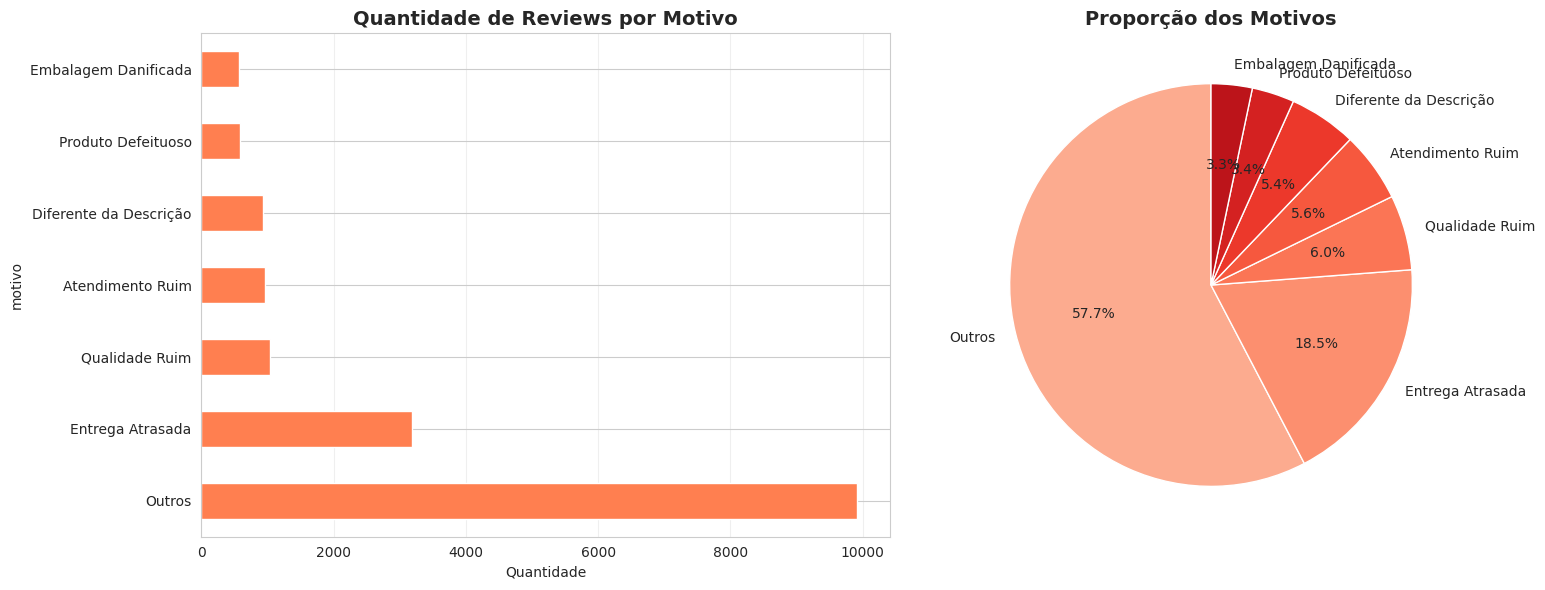

In [29]:
# ============================================================================
# PARTE 3: CLASSIFICAÇÃO POR PALAVRAS-CHAVE (Método Simples)
# ============================================================================
# Objetivo: Classificar os motivos baseado em palavras-chave específicas

# Dicionário de categorias com palavras-chave
categorias = {
    'Entrega Atrasada': [
        'atrasado', 'atraso', 'demora', 'demorou', 'prazo', 'tempo',
        'chegou tarde', 'dias', 'semanas', 'mes', 'demorado'
    ],
    'Produto Defeituoso': [
        'defeito', 'quebrado', 'não funciona', 'estragado', 'danificado',
        'com problema', 'quebrou', 'parou de funcionar', 'não liga'
    ],
    'Qualidade Ruim': [
        'qualidade', 'ruim', 'péssimo', 'péssima', 'barato', 'frágil', 'horrível',
        'inferior', 'mal feito', 'pior'
    ],
    'Diferente da Descrição': [
        'diferente', 'não é', 'enganosa', 'propaganda', 'mentira',
        'não corresponde', 'enganação', 'foto', 'descrição'
    ],
    'Embalagem Danificada': [
        'embalagem', 'caixa', 'lacre', 'amassado', 'rasgada',
        'aberta', 'violada', 'pacote'
    ],
    'Atendimento Ruim': [
        'atendimento', 'suporte', 'resposta', 'contato', 'vendedor',
        'não responde', 'mal atendido', 'ignorado'
    ]
}

def classificar_review(texto):
    """
    Classifica o review baseado em palavras-chave
    Retorna a categoria com maior score
    """
    texto_lower = str(texto).lower()
    scores = {}

    for categoria, palavras in categorias.items():
        # Conta quantas palavras-chave aparecem no texto
        score = sum(palavra in texto_lower for palavra in palavras)
        scores[categoria] = score

    # Retorna a categoria com maior score, ou 'Outros' se nenhuma palavra foi encontrada
    if max(scores.values()) > 0:
        return max(scores, key=scores.get)
    return 'Outros'

# Aplicar classificação
reviews_baixas['motivo'] = reviews_baixas['review_comment_message'].apply(classificar_review)

# Resultados da classificação
print("\n📊 DISTRIBUIÇÃO DE MOTIVOS")
print("=" * 60)
motivos_count = reviews_baixas['motivo'].value_counts()

for motivo, count in motivos_count.items():
    percentual = (count / len(reviews_baixas)) * 100
    barra = '█' * int(percentual / 2)
    print(f"{motivo:.<30} {count:>5} ({percentual:>5.1f}%) {barra}")

# Visualização
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico de barras
motivos_count.plot(kind='barh', ax=ax[0], color='coral')
ax[0].set_title('Quantidade de Reviews por Motivo', fontsize=14, fontweight='bold')
ax[0].set_xlabel('Quantidade')
ax[0].grid(axis='x', alpha=0.3)

# Gráfico de pizza
colors = plt.cm.Reds(np.linspace(0.3, 0.8, len(motivos_count)))
ax[1].pie(motivos_count.values, labels=motivos_count.index, autopct='%1.1f%%',
          colors=colors, startangle=90)
ax[1].set_title('Proporção dos Motivos', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()



🔤 TOP 15 BIGRAMAS (Pares de Palavras)
 1. não recebi................................... 1859x
 2. foi entregue................................. 1419x
 3. recebi produto............................... 1124x
 4. ainda não....................................  996x
 5. produto não..................................  816x
 6. não foi......................................  801x
 7. meu produto..................................  607x
 8. recebi apenas................................  569x
 9. não chegou...................................  560x
10. até agora....................................  506x
11. estou aguardando.............................  494x
12. nota fiscal..................................  472x
13. produto veio.................................  466x
14. até momento..................................  363x
15. comprei dois.................................  342x

🔤 TOP 15 TRIGRAMAS (Trios de Palavras)
 1. não recebi produto...........................  618x
 2. não foi entregue.....

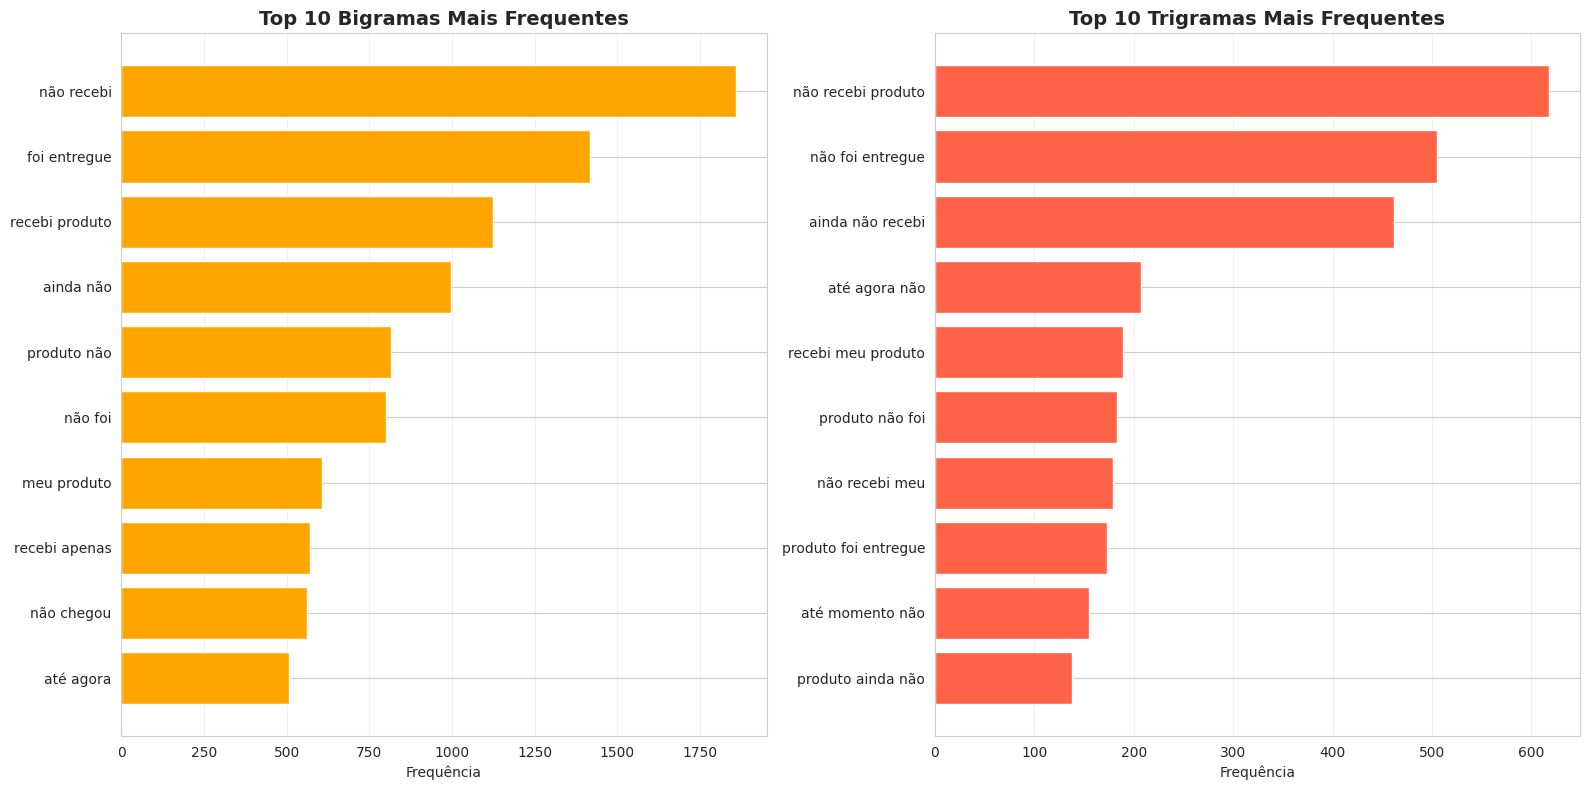

In [25]:
# ============================================================================
# PARTE 4: ANÁLISE DE PALAVRAS MAIS FREQUENTES (N-gramas)
# ============================================================================
# Objetivo: Identificar frases e palavras mais comuns nas reviews negativas

def extrair_ngrams(textos, n=2, top_n=20):
    """
    Extrai os n-gramas mais comuns
    n=1: palavras individuais
    n=2: pares de palavras (bigramas)
    n=3: trios de palavras (trigramas)
    """
    all_ngrams = []

    for texto in textos:
        # Limpar e tokenizar
        words = re.findall(r'\b\w+\b', str(texto).lower())

        # Remover palavras muito comuns (stop words básicas)
        stop_words = {'o', 'a', 'de', 'da', 'do', 'e', 'para', 'com', 'em', 'que', 'um', 'uma'}
        words = [w for w in words if w not in stop_words and len(w) > 2]

        if len(words) >= n:
            ngrams = list(zip(*[words[i:] for i in range(n)]))
            all_ngrams.extend(ngrams)

    most_common = Counter(all_ngrams).most_common(top_n)
    return [(' '.join(ngram), count) for ngram, count in most_common]

# Extrair bigramas e trigramas
print("\n🔤 TOP 15 BIGRAMAS (Pares de Palavras)")
print("=" * 60)
bigrams = extrair_ngrams(reviews_baixas['review_comment_message'], n=2, top_n=15)
for i, (bigram, count) in enumerate(bigrams, 1):
    print(f"{i:>2}. {bigram:.<45} {count:>4}x")

print("\n🔤 TOP 15 TRIGRAMAS (Trios de Palavras)")
print("=" * 60)
trigrams = extrair_ngrams(reviews_baixas['review_comment_message'], n=3, top_n=15)
for i, (trigram, count) in enumerate(trigrams, 1):
    print(f"{i:>2}. {trigram:.<45} {count:>4}x")

# Visualização
fig, ax = plt.subplots(1, 2, figsize=(16, 8))

# Bigramas
if bigrams:
    df_bigrams = pd.DataFrame(bigrams[:10], columns=['Bigrama', 'Frequência'])
    ax[0].barh(df_bigrams['Bigrama'], df_bigrams['Frequência'], color='orange')
    ax[0].set_title('Top 10 Bigramas Mais Frequentes', fontsize=14, fontweight='bold')
    ax[0].set_xlabel('Frequência')
    ax[0].grid(axis='x', alpha=0.3)
    ax[0].invert_yaxis()

# Trigramas
if trigrams:
    df_trigrams = pd.DataFrame(trigrams[:10], columns=['Trigrama', 'Frequência'])
    ax[1].barh(df_trigrams['Trigrama'], df_trigrams['Frequência'], color='tomato')
    ax[1].set_title('Top 10 Trigramas Mais Frequentes', fontsize=14, fontweight='bold')
    ax[1].set_xlabel('Frequência')
    ax[1].grid(axis='x', alpha=0.3)
    ax[1].invert_yaxis()

plt.tight_layout()
plt.show()


🎯 EXTRAÇÃO DE TÓPICOS COM LDA

📌 5 TÓPICOS IDENTIFICADOS:

Tópico 1:
  Palavras-chave: um, que, recebi, comprei, não, foi, dois, entregue, como, produto

Tópico 2:
  Palavras-chave: produto, não, entrega, prazo, ainda, recebi, foi, meu, chegou, que

Tópico 3:
  Palavras-chave: veio, uma, com, comprei, produto, só, recebi, nota, duas, na

Tópico 4:
  Palavras-chave: não, produto, que, com, muito, da, qualidade, bom, mais, mas

Tópico 5:
  Palavras-chave: não, recebi, até, que, estou, dia, comprei, agora, em, para


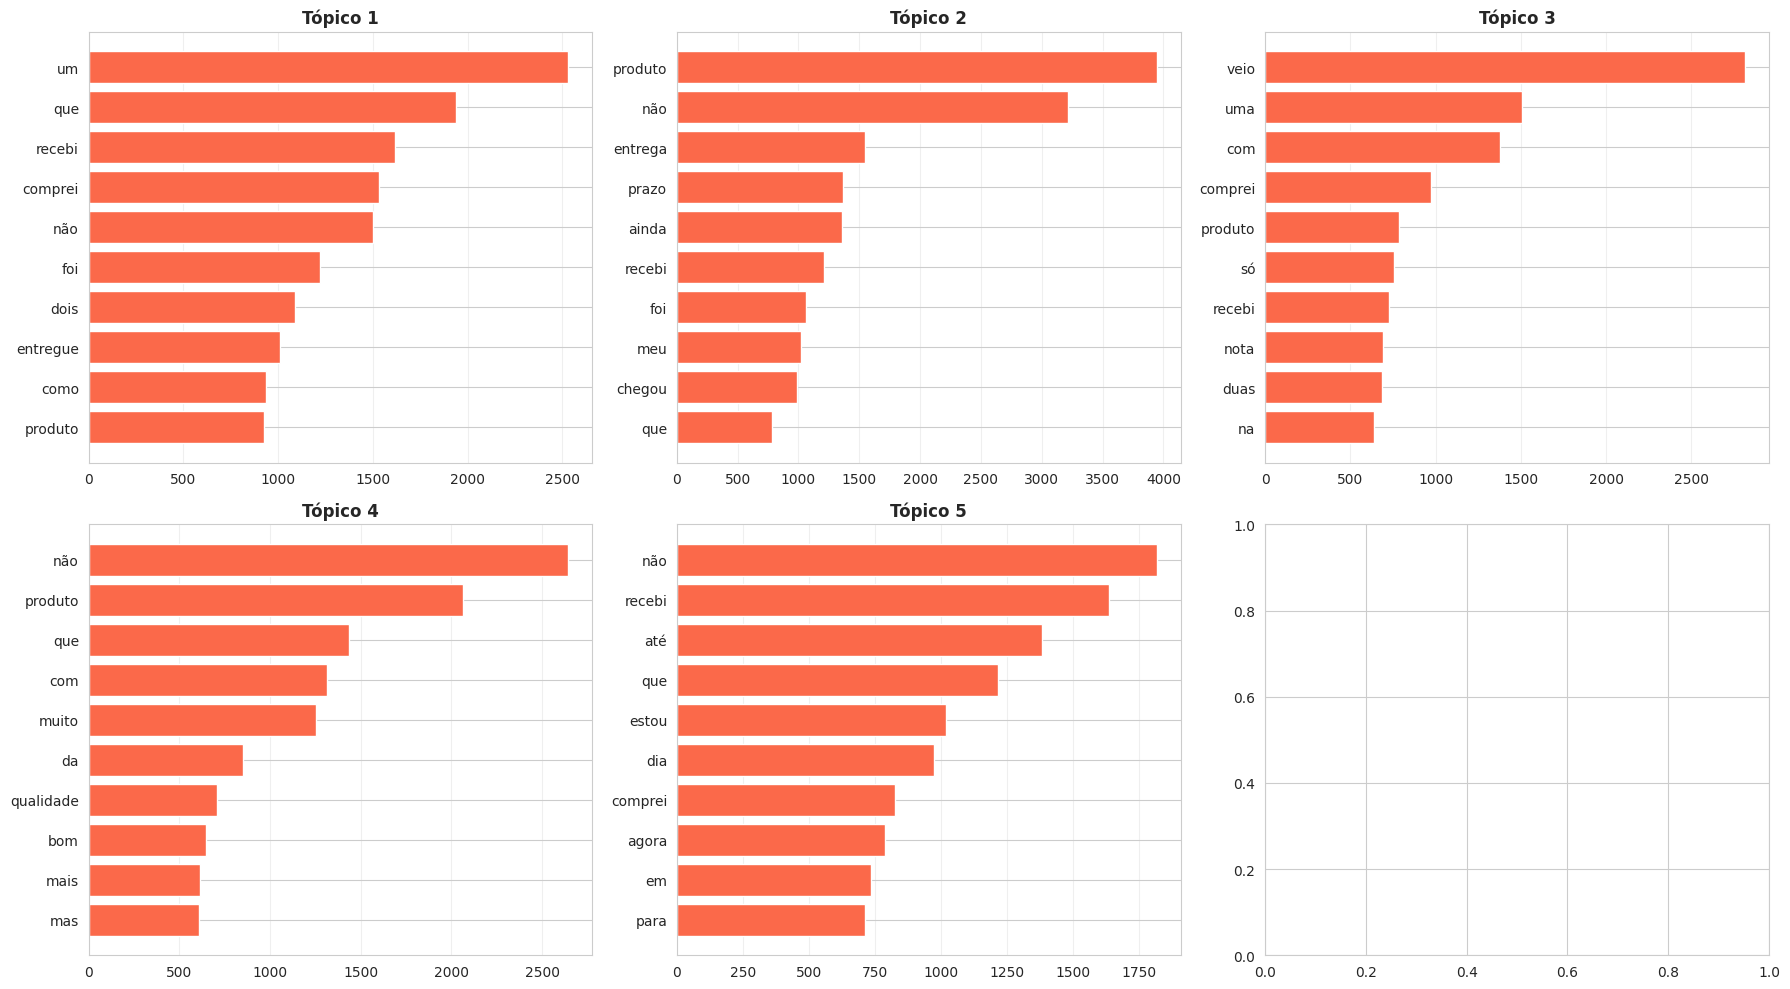

In [26]:
# ============================================================================
# PARTE 5: TOPIC MODELING COM LDA (Método Avançado)
# ============================================================================
# Objetivo: Descobrir tópicos automáticos usando algoritmo LDA

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# Preparar textos
textos_limpos = reviews_baixas['review_comment_message'].dropna()

# Vetorização
print("\n🎯 EXTRAÇÃO DE TÓPICOS COM LDA")
print("=" * 60)

vectorizer = CountVectorizer(
    max_df=0.9,        # Ignora palavras que aparecem em mais de 90% dos docs
    min_df=2,          # Ignora palavras que aparecem em menos de 2 docs
    max_features=500,  # Limita a 500 palavras mais importantes
    stop_words='english'
)

doc_term_matrix = vectorizer.fit_transform(textos_limpos)

# Aplicar LDA
n_topics = 5
lda = LatentDirichletAllocation(
    n_components=n_topics,
    random_state=42,
    max_iter=20
)

lda.fit(doc_term_matrix)

# Exibir tópicos
feature_names = vectorizer.get_feature_names_out()

print(f"\n📌 {n_topics} TÓPICOS IDENTIFICADOS:")
print("=" * 60)

for topic_idx, topic in enumerate(lda.components_):
    top_words = [feature_names[i] for i in topic.argsort()[:-11:-1]]
    print(f"\nTópico {topic_idx + 1}:")
    print(f"  Palavras-chave: {', '.join(top_words)}")

# Visualização da importância das palavras por tópico
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for topic_idx, topic in enumerate(lda.components_):
    if topic_idx >= 6:
        break
    top_indices = topic.argsort()[:-11:-1]
    top_words = [feature_names[i] for i in top_indices]
    top_values = [topic[i] for i in top_indices]

    axes[topic_idx].barh(top_words, top_values, color=plt.cm.Reds(0.5))
    axes[topic_idx].set_title(f'Tópico {topic_idx + 1}', fontsize=12, fontweight='bold')
    axes[topic_idx].invert_yaxis()
    axes[topic_idx].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

In [27]:
# ============================================================================
# PARTE 6: EXEMPLOS DE REVIEWS POR CATEGORIA
# ============================================================================
# Objetivo: Mostrar exemplos reais de cada tipo de problema

print("\n💬 EXEMPLOS DE REVIEWS POR MOTIVO")
print("=" * 80)

for motivo in motivos_count.index[:5]:  # Top 5 motivos
    print(f"\n{'='*80}")
    print(f"📌 {motivo.upper()}")
    print(f"{'='*80}")

    exemplos = reviews_baixas[reviews_baixas['motivo'] == motivo][
        ['review_comment_message', 'review_score']
    ].head(3)

    for i, (idx, row) in enumerate(exemplos.iterrows(), 1):
        stars = '⭐' * int(row['review_score']) + '☆' * (5 - int(row['review_score']))
        print(f"\n{i}. {stars}")
        print(f"   {row['review_comment_message'][:200]}...")



💬 EXEMPLOS DE REVIEWS POR MOTIVO

📌 OUTROS


KeyError: "['review_score'] not in index"

In [28]:
# ============================================================================
# PARTE 7: ANÁLISE TEMPORAL (Se houver data)
# ============================================================================
# Objetivo: Ver se os problemas variam ao longo do tempo

# Verificar se existe coluna de data
if 'review_creation_date' in reviews_baixas.columns:
    print("\n📅 ANÁLISE TEMPORAL DOS PROBLEMAS")
    print("=" * 60)

    # Converter para datetime
    reviews_baixas['review_date'] = pd.to_datetime(reviews_baixas['review_creation_date'])
    reviews_baixas['mes_ano'] = reviews_baixas['review_date'].dt.to_period('M')

    # Evolução temporal por motivo
    evolucao = reviews_baixas.groupby(['mes_ano', 'motivo']).size().unstack(fill_value=0)

    # Plotar
    fig, ax = plt.subplots(figsize=(14, 6))
    evolucao.plot(kind='line', ax=ax, marker='o', linewidth=2)
    ax.set_title('Evolução Temporal dos Problemas', fontsize=14, fontweight='bold')
    ax.set_xlabel('Período')
    ax.set_ylabel('Quantidade de Reviews')
    ax.legend(title='Motivo', bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("\n⚠️ Coluna de data não encontrada. Pulando análise temporal.")


⚠️ Coluna de data não encontrada. Pulando análise temporal.


In [16]:
# ============================================================================
# PARTE 8: EXPORTAR RESULTADOS
# ============================================================================
# Objetivo: Salvar o dataset classificado para análises futuras

# Salvar CSV com classificações
output_file = 'reviews_classificadas.csv'
reviews_baixas.to_csv(output_file, index=False)
print(f"\n✅ Arquivo salvo: {output_file}")

# Criar resumo estatístico
resumo = {
    'Total de Reviews Negativas': len(reviews_baixas),
    #'Score Médio': reviews_baixas['review_score'].mean(),
    'Motivo Mais Comum': motivos_count.index[0],
    'Percentual do Principal': f"{(motivos_count.iloc[0] / len(reviews_baixas) * 100):.1f}%"
}

print("\n📊 RESUMO EXECUTIVO")
print("=" * 60)
for chave, valor in resumo.items():
    print(f"{chave:.<40} {valor}")

print("\n✅ Análise completa!")


✅ Arquivo salvo: reviews_classificadas.csv

📊 RESUMO EXECUTIVO
Total de Reviews Negativas.............. 100
Motivo Mais Comum....................... Outros
Percentual do Principal................. 66.0%

✅ Análise completa!
